In [1]:
using Pkg
Pkg.build("CUDA")

┌ Warning: The active manifest file has dependencies that were resolved with a different julia version (1.10.10). Unexpected behavior may occur.
└ @ C:\Users\Vedant\Downloads\Projects\Jaynes Cummings Hubbard Model Simulation\Manifest.toml:0
┌ Warning: The project dependencies or compat requirements have changed since the manifest was last resolved.
│ It is recommended to `Pkg.resolve()` or consider `Pkg.update()` if necessary.
└ @ Pkg.API C:\Users\Vedant\AppData\Local\Programs\Julia-1.12.0\share\julia\stdlib\v1.12\Pkg\src\API.jl:1211
Precompiling packages...
              ✗ MbedTLS_jll
    781.0 ms  ✓ CUDA_Driver_jll
  1 dependency successfully precompiled in 2 seconds. 27 already precompiled.
Precompiling packages...
              ✗ MbedTLS_jll
   2479.2 ms  ✓ CUDA_Runtime_jll
  1 dependency successfully precompiled in 4 seconds. 29 already precompiled.
Precompiling packages...
    930.8 ms  ✓ SimpleUnPack
    844.0 ms  ✓ ConcreteStructs
    811.7 ms  ✓ IteratorInterfaceExtensions
   

In [2]:
using Pkg
Pkg.update()      # This upgrades the lockfile to 1.12
Pkg.build("CUDA") # This seals the C++ bindings to your drivers one last time

    Updating registry at `C:\Users\Vedant\.julia\registries\General.toml`
     Project No packages added to or removed from `C:\Users\Vedant\Downloads\Projects\Jaynes Cummings Hubbard Model Simulation\Project.toml`
    Updating `C:\Users\Vedant\Downloads\Projects\Jaynes Cummings Hubbard Model Simulation\Manifest.toml`
  [aea7be01] ↑ PrecompileTools v1.2.1 ⇒ v1.3.3 [loaded: v1.2.1]
  [10745b16] ↑ Statistics v1.10.0 ⇒ v1.11.1
  [c8ffd9c3] ↑ MbedTLS_jll v2.28.2+1 ⇒ v2.28.1010+0
  [0dad84c5] ↑ ArgTools v1.1.1 ⇒ v1.1.2
  [56f22d72] ~ Artifacts ⇒ v1.11.0
  [2a0f44e3] ~ Base64 ⇒ v1.11.0
  [ade2ca70] ~ Dates ⇒ v1.11.0
  [8ba89e20] ~ Distributed ⇒ v1.11.0
  [7b1f6079] ~ FileWatching ⇒ v1.11.0
  [9fa8497b] ~ Future ⇒ v1.11.0
  [b77e0a4c] ~ InteractiveUtils ⇒ v1.11.0
  [ac6e5ff7] + JuliaSyntaxHighlighting v1.12.0
  [4af54fe1] ~ LazyArtifacts ⇒ v1.11.0
  [76f85450] ~ LibGit2 ⇒ v1.11.0
  [8f399da3] ~ Libdl ⇒ v1.11.0
  [37e2e46d] ~ LinearAlgebra ⇒ v1.12.0
  [56ddb016] ~ Logging ⇒ v1.11.0
  [d6f4376e

In [ ]:
using Pkg
Pkg.activate(".") # Ensures we stay locked to your project environment
println("CUDA Functional: ", CUDA.functional())

In [3]:


using QuantumToolbox
using CUDA



# --- 1. System Parameters ---
N_cutoff = 20     # Max photons per cavity
ω_c = 1.0         # Cavity resonance frequency
ω_a = 1.0         # Atom transition frequency
g = 0.05          # Jaynes-Cummings coupling strength
J = 0.02          # Photon hopping strength between cavities
κ = 0.01          # Cavity leakage rate
γ = 0.01          # Atom spontaneous emission rate

# --- 2. Base Operators ---
a = destroy(N_cutoff)
adag = create(N_cutoff)
sm = sigmam()
sp = sigmap()
I_cav = qeye(N_cutoff)
I_atom = qeye(2)

# --- 3. Hilbert Space Tensor Products ---
# Site 1
a1  = tensor(a, I_atom, I_cav, I_atom)
sm1 = tensor(I_cav, sm, I_cav, I_atom)
adag1 = a1'
sp1   = sm1'

# Site 2
a2  = tensor(I_cav, I_atom, a, I_atom)
sm2 = tensor(I_cav, I_atom, I_cav, sm)
adag2 = a2'
sp2   = sm2'

# --- 4. Build Hamiltonian & Transfer to GPU ---
H_site1 = ω_c * adag1 * a1 + ω_a * sp1 * sm1
H_site2 = ω_c * adag2 * a2 + ω_a * sp2 * sm2
H_JC1 = g * (adag1 * sm1 + a1 * sp1)
H_JC2 = g * (adag2 * sm2 + a2 * sp2)
H_hop = -J * (adag1 * a2 + a1 * adag2)

H_cpu = H_site1 + H_site2 + H_JC1 + H_JC2 + H_hop
H_gpu = cu(H_cpu) 

# --- 5. Lindblad Collapse Operators (GPU) ---
c_ops_cpu = [
    sqrt(κ) * a1,   # Cavity 1 leakage
    sqrt(γ) * sm1,  # Atom 1 emission
    sqrt(κ) * a2,   # Cavity 2 leakage
    sqrt(γ) * sm2   # Atom 2 emission
]
# Broadcast transfer all collapse operators to the GPU
c_ops_gpu = cu.(c_ops_cpu) 

# --- 6. Initial State & Evolution ---
# Start with 1 photon in Cavity 1, everything else ground state
psi0_cpu = tensor(basis(N_cutoff, 1), basis(2, 0), basis(N_cutoff, 0), basis(2, 0))
psi0_gpu = cu(psi0_cpu)

tlist = range(0, 50, length=200)

# Track the photon number in both cavities during the simulation
e_ops_gpu = [cu(adag1 * a1), cu(adag2 * a2)]

println("\nStarting GPU mesolve...")
result = mesolve(H_gpu, psi0_gpu, tlist, c_ops_gpu; e_ops=e_ops_gpu)
println("Simulation Complete!")


Starting GPU mesolve...


[mesolve] 100%|███████████████████████████| Time: 0:04:57 ( 1.49  s/it):37 ( 4.13  s/it)


Simulation Complete!


In [3]:
println("Hello from Julia!")
1 + 1

Hello from Julia!


2

[ Info: Precompiling IJuliaExt [64482eec-cc57-5312-bea1-9f24eb636db7] 
[ Info: Precompiling IJuliaExt [2f4121a4-3b3a-5ce6-9c5e-1f2673ce168a] 


1. Extracting time vector...
2. Extracting expectation values...
3. Building the plot (This might take 30-60 seconds the first time!)...
4. Pushing plot to VS Code display...


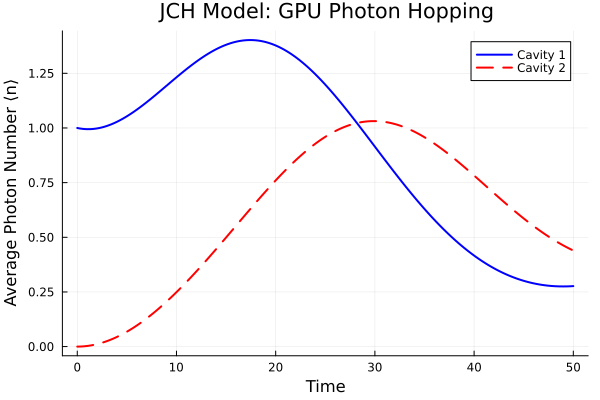

Done!


In [4]:
using Plots
gr() # explicitly force the GR rendering backend

println("1. Extracting time vector...")
t = result.times

println("2. Extracting expectation values...")
# Safely handle the data whether QuantumToolbox saved it as a Matrix or a Vector of Vectors
if result.expect isa AbstractMatrix
    cav1 = real.(Array(result.expect[1, :]))
    cav2 = real.(Array(result.expect[2, :]))
else
    cav1 = real.(Array(result.expect[1]))
    cav2 = real.(Array(result.expect[2]))
end

println("3. Building the plot (This might take 30-60 seconds the first time!)...")
p = plot(t, cav1, 
    label="Cavity 1", 
    linewidth=2, 
    color=:blue,
    xlabel="Time", 
    ylabel="Average Photon Number ⟨n⟩", 
    title="JCH Model: GPU Photon Hopping",
    legend=:topright,
    grid=true)

plot!(p, t, cav2, 
    label="Cavity 2", 
    linewidth=2, 
    linestyle=:dash, 
    color=:red)

println("4. Pushing plot to VS Code display...")
display(p)
println("Done!")

In [15]:
using CUDA

# We need the CPU versions of the expectation operators for a fair fight
e_ops_cpu = [adag1 * a1, adag2 * a2]
t_bench = range(0, 10, length=50)

println("🔥 Warming up the compilers (ignoring this time)...")
mesolve(H_cpu, psi0_cpu, [0.0, 0.1], c_ops_cpu, e_ops=e_ops_cpu, progress_bar=false)
CUDA.@sync mesolve(H_gpu, psi0_gpu, [0.0, 0.1], c_ops_gpu, e_ops=e_ops_gpu, progress_bar=false)

println("\n🏁 Starting CPU Benchmark...")
cpu_time = @elapsed mesolve(H_cpu, psi0_cpu, t_bench, c_ops_cpu, e_ops=e_ops_cpu, progress_bar=false)
println("CPU Time: ", round(cpu_time, digits=4), " seconds")

println("\n🏁 Starting GPU Benchmark...")
# CUDA.@sync forces the CPU stopwatch to wait until the GPU physically finishes
gpu_time = @elapsed CUDA.@sync mesolve(H_gpu, psi0_gpu, t_bench, c_ops_gpu, e_ops=e_ops_gpu, progress_bar=false)
println("GPU Time: ", round(gpu_time, digits=4), " seconds")

if gpu_time < cpu_time
    println("\n🏆 GPU Wins! It was ", round(cpu_time/gpu_time, digits=1), "x faster.")
else
    println("\n🏆 CPU Wins! It was ", round(gpu_time/cpu_time, digits=1), "x faster.")
end

🔥 Warming up the compilers (ignoring this time)...

🏁 Starting CPU Benchmark...
CPU Time: 0.0045 seconds

🏁 Starting GPU Benchmark...
GPU Time: 0.3139 seconds

🏆 CPU Wins! It was 69.8x faster.


🚀 Starting the CPU vs GPU Scaling Benchmark...
Testing N_cutoff = 3...
Testing N_cutoff = 5...
Testing N_cutoff = 7...
Testing N_cutoff = 9...
Testing N_cutoff = 11...
Testing N_cutoff = 13...
✅ Benchmark Complete! Generating Plot...


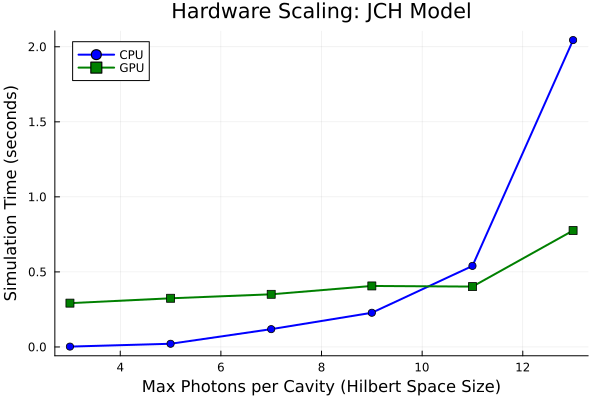

In [18]:
using QuantumToolbox
using CUDA
using Plots
gr()

# We will test cutoffs from 3 up to 13 photons
cutoffs = 3:2:13 
cpu_times = Float64[]
gpu_times = Float64[]

println("🚀 Starting the CPU vs GPU Scaling Benchmark...")

for N in cutoffs
    println("Testing N_cutoff = $N...")
    
    # 1. Rebuild the operators for the new Hilbert space size
    a = destroy(N); I_cav = qeye(N)
    sm = sigmam();  I_atom = qeye(2)
    
    a1  = tensor(a, I_atom, I_cav, I_atom)
    sm1 = tensor(I_cav, sm, I_cav, I_atom)
    a2  = tensor(I_cav, I_atom, a, I_atom)
    sm2 = tensor(I_cav, I_atom, I_cav, sm)
    
    adag1, sp1 = a1', sm1'
    adag2, sp2 = a2', sm2'
    
    # 2. Rebuild the Hamiltonian
    H_cpu = 1.0 * adag1 * a1 + 1.0 * sp1 * sm1 + 1.0 * adag2 * a2 + 1.0 * sp2 * sm2 +
            0.05 * (adag1 * sm1 + a1 * sp1) + 0.05 * (adag2 * sm2 + a2 * sp2) -
            0.02 * (adag1 * a2 + a1 * adag2)
            
    c_ops_cpu = [0.01 * a1, 0.01 * sm1, 0.01 * a2, 0.01 * sm2]
    e_ops_cpu = [adag1 * a1]
    psi0_cpu = tensor(basis(N, 1), basis(2, 0), basis(N, 0), basis(2, 0))
    
    # 3. Transfer to GPU
    H_gpu = cu(H_cpu)
    c_ops_gpu = cu.(c_ops_cpu)
    e_ops_gpu = [cu(adag1 * a1)]
    psi0_gpu = cu(psi0_cpu)
    
    # Short time vector for benchmarking
    t_bench = range(0, 5, length=10)
    
    # 4. Silent Warmup
    mesolve(H_cpu, psi0_cpu, [0.0, 0.1], c_ops_cpu, e_ops=e_ops_cpu, progress_bar=false)
    CUDA.@sync mesolve(H_gpu, psi0_gpu, [0.0, 0.1], c_ops_gpu, e_ops=e_ops_gpu, progress_bar=false)
    
    # 5. The Actual Race
    ct = @elapsed mesolve(H_cpu, psi0_cpu, t_bench, c_ops_cpu, e_ops=e_ops_cpu, progress_bar=false)
    gt = @elapsed CUDA.@sync mesolve(H_gpu, psi0_gpu, t_bench, c_ops_gpu, e_ops=e_ops_gpu, progress_bar=false)
    
    push!(cpu_times, ct)
    push!(gpu_times, gt)
end

println("✅ Benchmark Complete! Generating Plot...")

# 6. Plot the results
p = plot(cutoffs, cpu_times, 
    label="CPU", 
    marker=:circle, 
    linewidth=2, 
    color=:blue,
    xlabel="Max Photons per Cavity (Hilbert Space Size)", 
    ylabel="Simulation Time (seconds)", 
    title="Hardware Scaling: JCH Model", 
    legend=:topleft,
    grid=true)

plot!(p, cutoffs, gpu_times, 
    label="GPU", 
    marker=:square, 
    linewidth=2,
    color=:green)

display(p)

In [2]:
using QuantumToolbox
using CUDA

function build_jch_1d_gpu(N_sites::Int, N_cutoff::Int; 
                          ω_c=1.0, ω_a=1.0, g=0.05, J=0.02, κ=0.01, γ=0.01)
    
    println("Building $N_sites-site JCH lattice (Max Photons: $N_cutoff)...")
    
    # 1. Fundamental Operators
    a_base = destroy(N_cutoff)
    sm_base = sigmam()
    I_cav = qeye(N_cutoff)
    I_atom = qeye(2)
    
    # 2. The Embedding Helper Function
    # This places a specific operator at the correct position in the 2N-length chain
    function embed(op, pos)
        op_list = QuantumObject[] 
        for i in 1:(2 * N_sites)
            if i == pos
                push!(op_list, op)
            elseif isodd(i) # Odd positions are cavities
                push!(op_list, I_cav)
            else            # Even positions are atoms
                push!(op_list, I_atom)
            end
        end
        return tensor(op_list...)
    end

    # 3. Generate all Site Operators
    a = [embed(a_base, 2i - 1) for i in 1:N_sites]
    adag = [a[i]' for i in 1:N_sites]
    sm = [embed(sm_base, 2i) for i in 1:N_sites]
    sp = [sm[i]' for i in 1:N_sites]

    # 4. Construct the Hamiltonian
    # Site energies and Jaynes-Cummings coupling
    H_cpu = sum(ω_c * adag[i] * a[i] + 
                ω_a * sp[i] * sm[i] + 
                g * (adag[i] * sm[i] + a[i] * sp[i]) for i in 1:N_sites)
    
    # Photon Hopping (Open Boundary Conditions: 1 to N-1)
    if N_sites > 1
        H_cpu += sum(-J * (adag[i] * a[i+1] + a[i] * adag[i+1]) for i in 1:(N_sites-1))
    end

    # 5. Construct Lindblad Collapse Operators
    c_ops_cpu = QuantumObject[]
    for i in 1:N_sites
        push!(c_ops_cpu, sqrt(κ) * a[i])
        push!(c_ops_cpu, sqrt(γ) * sm[i])
    end

    # 6. Push to GPU
    println("Transferring matrices to RTX 4070...")
    H_gpu = cu(H_cpu)
    c_ops_gpu = cu.(c_ops_cpu)
    
    # We return the cavity operators so you can use them as e_ops in the solver
    a_gpu = cu.(a)
    adag_gpu = cu.(adag)
    
    return H_gpu, c_ops_gpu, a_gpu, adag_gpu
end

build_jch_1d_gpu (generic function with 1 method)

Louivillian matrix solver unitary


In [4]:
# Setup a 5-site lattice with a cutoff of 3 photons per cavity
N_sites = 5
N_cutoff = 3
H_gpu, c_ops_gpu, a_gpu, adag_gpu = build_jch_1d_gpu(N_sites, N_cutoff)

# Create tracking operators (expectation values for photon number at EACH site)
e_ops_gpu = [adag_gpu[i] * a_gpu[i] for i in 1:N_sites]

# Initial State: 1 photon in Site 1, everything else empty
# We build this by tensoring the states in order: (Cav1, Atom1, Cav2, Atom2...)
# Initial State: 1 photon in Site 1, everything else empty
state_list = QuantumObject[]
for i in 1:N_sites
    if i == 1
        push!(state_list, basis(N_cutoff, 1))
    else
        push!(state_list, basis(N_cutoff, 0)) 
    end
    push!(state_list, basis(2, 0))            
end

psi0_cpu = tensor(state_list...)
psi0_gpu = cu(psi0_cpu)

tlist = range(0, 150, length=400) 

println("\nRunning 5-Site Unitary Simulation (sesolve)...")
# Notice we use `sesolve` instead of `mesolve` and completely drop `c_ops_gpu`
result_5site = sesolve(H_gpu, psi0_gpu, tlist; e_ops=e_ops_gpu)
println("Done!")

Building 5-site JCH lattice (Max Photons: 3)...
Transferring matrices to RTX 4070...

Running 5-Site Unitary Simulation (sesolve)...


[sesolve] 100%|███████████████████████████| Time: 0:00:03 ( 9.89 ms/it)


Done!


Building the Heatmap...


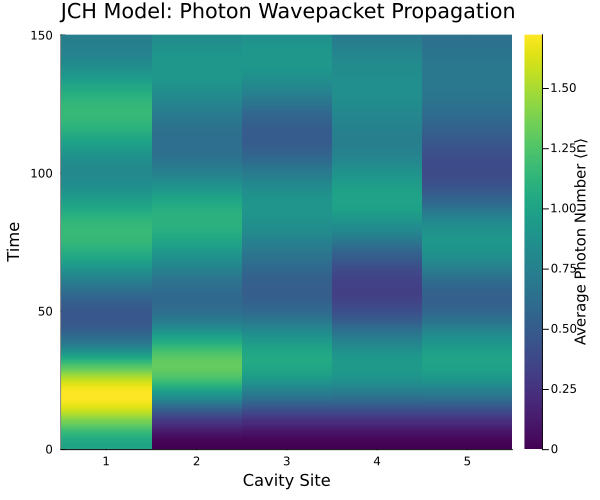

In [8]:
using Plots
gr()

# 1. Extract the time vector
t = result_5site.times

# 2. Extract the data safely into a matrix (rows = time, columns = sites)
z_data = zeros(length(t), N_sites)

for i in 1:N_sites
    if result_5site.expect isa AbstractMatrix
        z_data[:, i] .= real.(Array(result_5site.expect[i, :]))
    else
        z_data[:, i] .= real.(Array(result_5site.expect[i]))
    end
end

println("Building the Heatmap...")

# 3. Create the 2D Heatmap
p_heat = heatmap(1:N_sites, t, z_data,
    c = :viridis, # A great scientific color map
    xlabel = "Cavity Site",
    ylabel = "Time",
    title = "JCH Model: Photon Wavepacket Propagation",
    colorbar_title = "Average Photon Number ⟨n⟩",
    xticks = 1:N_sites,
    size = (600, 500)
)

# Force VS Code to display it
display(p_heat)

Monte Carlo


In [ ]:
# --- 1. Monte Carlo Solver ---
# Bypasses the memory crash by averaging 100 stochastic quantum jump trajectories
println("\nStarting GPU Monte Carlo Simulation (100 Trajectories)...")
result_mc = mcsolve(H_gpu, psi0_gpu, tlist, c_ops_gpu; e_ops=e_ops_gpu, ntraj=100)
println("Simulation Complete!")

# --- 2. Data Extraction & Heatmap Plotting ---
using Plots
gr()

# Pre-allocate the matrix for the heatmap (rows = time, cols = physical sites)
z_data_mc = zeros(length(tlist), N_sites)

for i in 1:N_sites
    if result_mc.expect isa AbstractMatrix
        z_data_mc[:, i] .= real.(Array(result_mc.expect[i, :]))
    else
        z_data_mc[:, i] .= real.(Array(result_mc.expect[i]))
    end
end

println("Building the Open System Heatmap...")
p_heat_mc = heatmap(1:N_sites, tlist, z_data_mc,
    c = :magma, # Using 'magma' to visually distinguish it from the unitary plot
    xlabel = "Cavity Site",
    ylabel = "Time",
    title = "Open JCH Model: Wavepacket with Dissipation",
    colorbar_title = "Average Photon Number ⟨n⟩",
    xticks = 1:N_sites,
    size = (600, 500)
)

# Force VS Code to display it
display(p_heat_mc)


Starting GPU Monte Carlo Simulation (100 Trajectories)...


[mcsolve] 100%|███████████████████████████| Time: 0:07:16 ( 4.36  s/it)
